### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Alan Velasco


**Fecha:** 6/04/2026

## Examen Practico - Segundo Parcial

#### 0) Cargar una de las imágenes histológicas

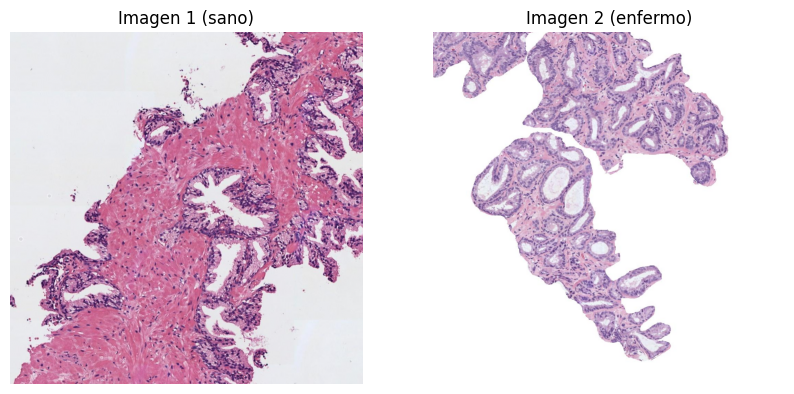

In [18]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen
import matplotlib.pyplot as plt
from skimage import io, img_as_float

# rutas de las imagenes
rutas = ["histo_1.jpg", "histo_2.jpg"]

# titulos
titulos = ["Imagen 1 (sano)", "Imagen 2 (enfermo)"]

# leer imagenes en RGB
imagenes = [io.imread(r) for r in rutas]

# normalizar al rango [0,1]
imagenes = [img_as_float(img) for img in imagenes]

# visualizamos las imagenes
fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, img in enumerate(imagenes):
    ax[i].imshow(img)
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

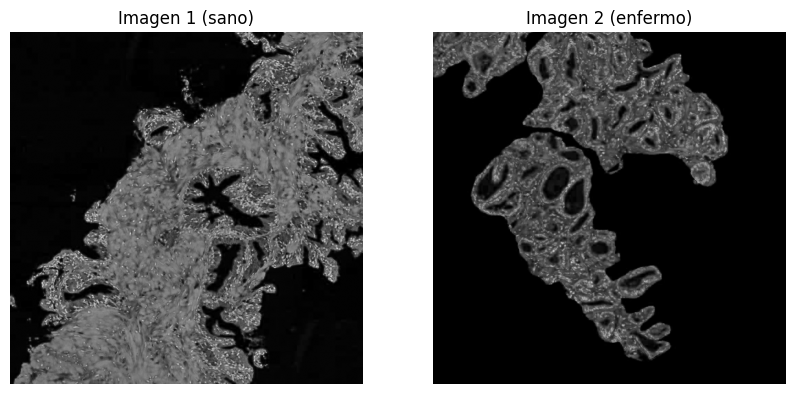

In [19]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

# creao la ista donde guardaremos el canal magenta de cada imagen
magentas = []

# creamos una figura para visualizar las dos imagenes
fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, img in enumerate(imagenes):

    # Separar los canales de color RGB
    R = img[:,:,0]   # canal rojo
    G = img[:,:,1]   # canal verde
    B = img[:,:,2]   # canal azul

    # calculamos el canal negro (K) del modelo CMYK
    K = 1 - np.maximum.reduce([R,G,B])

    # calculamos el canal magenta usando la fórmula de conversión RGB → CMYK
    M = (1 - G - K) / (1 - K + 1e-8)

    # guardar el canal magenta
    magentas.append(M)

    # mostramos el canal magenta en escala de grises
    ax[i].imshow(M, cmap="gray")
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

# Mostramos la figura
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

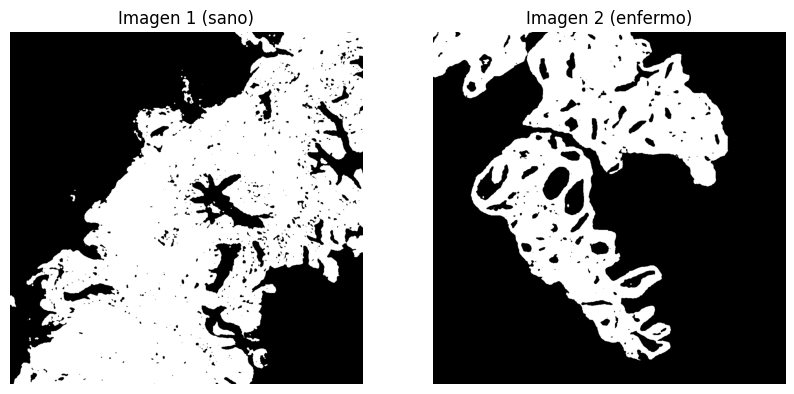

In [20]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

from skimage.filters import gaussian, threshold_otsu

# creamos una ista para guardar las mascaras binarias
mascaras = []

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, M in enumerate(magentas):

    # convertmos la imagen al rango 0–255 y tipo uint8 (necesario para Otsu)
    M_uint8 = (M*255).astype(np.uint8)

    # aplicamos un filtro gaussiano para suavizar la imagen y reducir ruido
    suavizada = gaussian(M_uint8, sigma=1)

    # calculamos automaticamente el umbral usando el método de Otsu
    t = threshold_otsu(suavizada)

    # Creamos una mascara binaria
    # 1 = lumen o fondo
    # 0 = resto del tejido
    mask = suavizada > t

    # Guardar la mascara
    mascaras.append(mask)

    # mostrar resultado
    ax[i].imshow(mask, cmap="gray")
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\admin\AppData\Local\Temp\ipykernel_7832\81776951.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  limpia = remove_small_objects(mask, min_size=300)


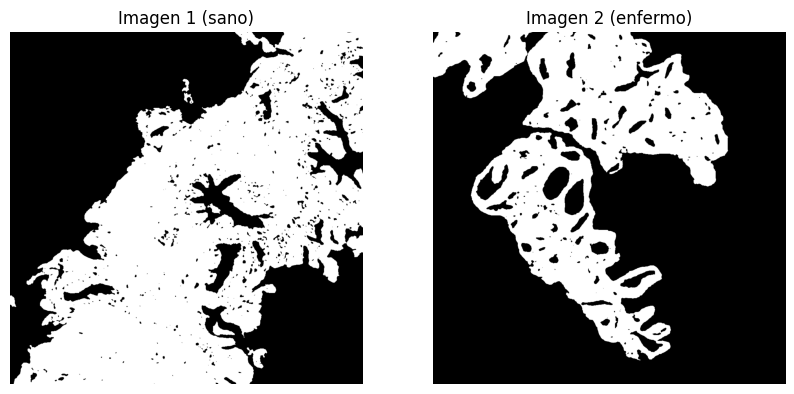

In [21]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

#importamos la funcion remove_small_objects sirve para eliminar objetos pequeños de una imagen binaria o etiquetada.
from skimage.morphology import remove_small_objects

# creamos una lista donde guardaremos la mascara limpia
mascaras_limpias = []

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, mask in enumerate(mascaras):

    # liminamos objetos cuya área sea menor a 300 píxeles
    limpia = remove_small_objects(mask, min_size=300)

    # guardamos la mascara limpia
    mascaras_limpias.append(limpia)

    # mostramos resultados
    ax[i].imshow(limpia, cmap="gray")
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

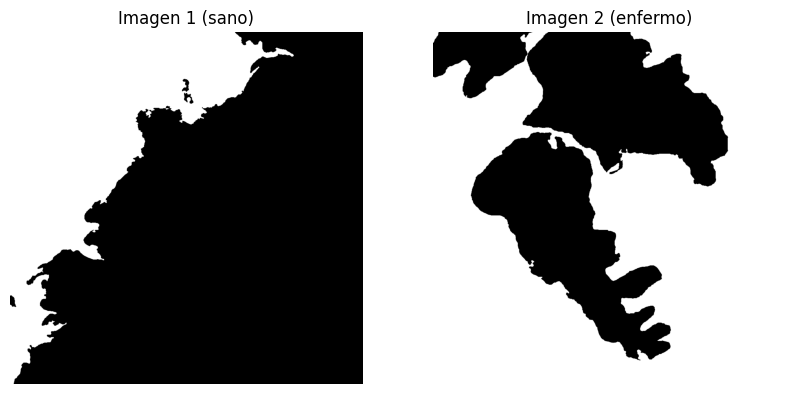

In [27]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

#utilizamos la funcion flood sirve para seleccionar o llenar una región de una imagen que tiene valores similares partiendo desde un punto inicial.
from skimage.segmentation import flood

# creamos una lista para guardar los lúmenes detectados
lumenes = []

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, img in enumerate(mascaras_limpias):

    # creamos una imagen vacia del mismo tamaño
    lumen = np.zeros_like(img)

    # definir primera semilla para iniciar el crecimiento de región
    seed1 = (10,10)

    # obtenemos la región conectada a la semilla
    region1 = flood(img, seed1)

    #  la segunda semilla la utilizamos  para detectar otra posible región
    seed2 = (100,100)

    # crecimiento desde la segunda semilla
    region2 = flood(img, seed2)

    # unimos ambas regiones detectadas
    lumen = region1 | region2

    # guardamos resultado
    lumenes.append(lumen)

    # mostramos la máscara de lúmenes
    ax[i].imshow(lumen, cmap="gray")
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 5) Rellenar los objetos de los lúmenes

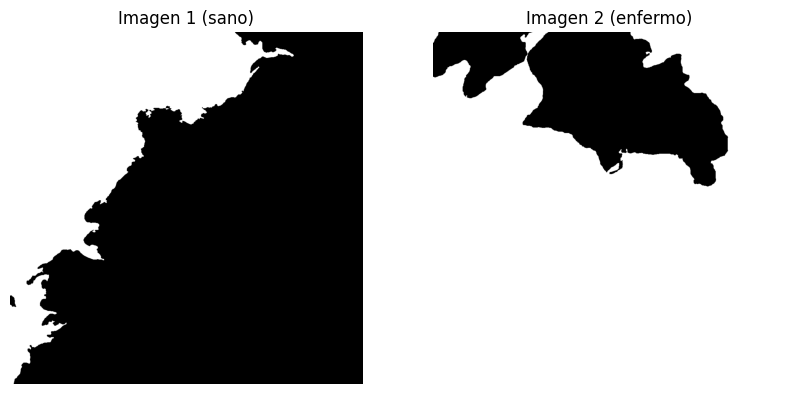

In [23]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

#utilizamos la funcion binary_fill_holes para rellenar huecosdentro de objetos en una imagen binaria.
from scipy.ndimage import binary_fill_holes

# creamos una lista para guardar los lúmenes rellenos
rellenos = []

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, lumen in enumerate(lumenes):

    # rellenamos huecos dentro de las regiones binarias
    fill = binary_fill_holes(lumen)

    # guardamos resultado
    rellenos.append(fill)

    # Mostramos la imagen
    ax[i].imshow(fill, cmap="gray")
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()


#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

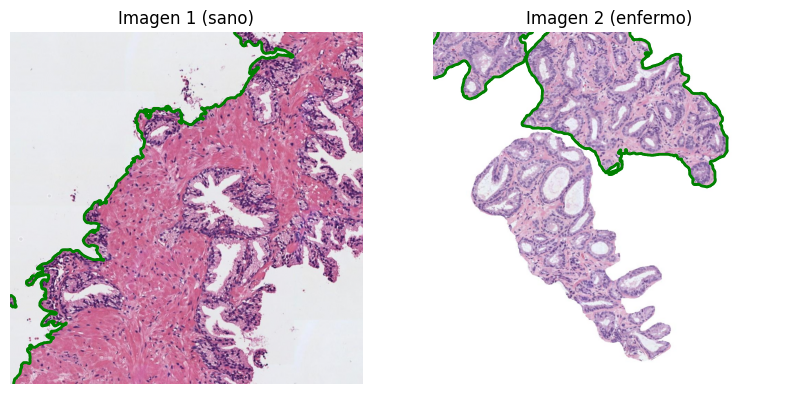

In [24]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

#utilizamos la funcion find_contours para detectar los contornos de los objetos en una imagen
from skimage.measure import find_contours

# creamos una lista para guardar contornos
contornos_todos = []

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, img in enumerate(rellenos):

    # copiamos la imagen original para dibujar sobre ella
    salida = imagenes[i].copy()

    # detectamos contornos en la máscara binaria
    contornos = find_contours(img, 0.8)

    # guardamos contornos
    contornos_todos.append(contornos)

    # mostramos imagen original
    ax[i].imshow(salida)

    # dibujamos cada contorno en color verde
    for c in contornos:
        ax[i].plot(c[:,1], c[:,0], color="green", linewidth=2)

    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 7) Identificar y cropear el lumen más grande

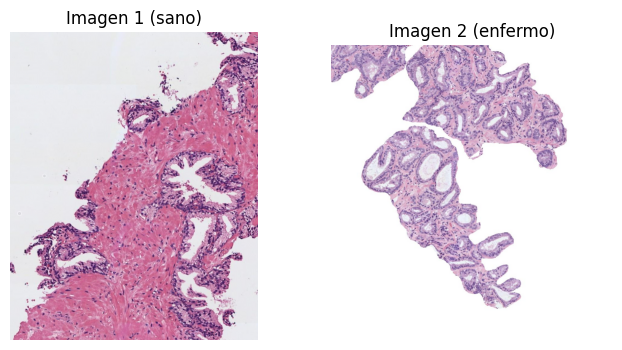

In [25]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

#utilizamos la funcion label, regionprops que se usan para identificar objetos en una imagen y obtener información sobre cada uno de ellos.
from skimage.measure import label, regionprops

# guardamos una lista para guardar regiones detectadas
regiones = []

fig, ax = plt.subplots(1,2, figsize=(8,4))

for i, img in enumerate(rellenos):

    # etiquetamos regiones conectadas en la imagen
    etiquetas = label(img)

    # obtenemos propiedades de cada región
    props = regionprops(etiquetas)

    # seleccionamos la region con mayor área
    mayor = max(props, key=lambda x: x.area)

    regiones.append(mayor)

    # obteneos coordenadas del bounding box
    minr, minc, maxr, maxc = mayor.bbox

    # recortamos el lumen desde la imagen original
    crop = imagenes[i][minr:maxr, minc:maxc]

    # mostramos lumen recortado
    ax[i].imshow(crop)
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [26]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.

import pandas as pd

# creamos una lista donde guardaremos las características
datos = []

for i, r in enumerate(regiones):

    # Área del lumen
    area = r.area

    # Área del bounding box
    bbox = r.bbox_area

    # Área convexa
    convexa = r.convex_area

    # Excentricidad de la región
    excentricidad = r.eccentricity

    # Diámetro equivalente
    diam_eq = r.equivalent_diameter

    # Extensión
    extension = r.extent

    # Diámetro de Feret
    feret = r.feret_diameter_max

    # Longitud del eje mayor
    eje_mayor = r.major_axis_length

    # Longitud del eje menor
    eje_menor = r.minor_axis_length

    # Orientación
    orientacion = r.orientation

    # Perímetro
    perimetro = r.perimeter

    # Solidez
    solidez = r.solidity

    # Compacidad
    compacidad = (4*np.pi*area)/(perimetro**2) if perimetro>0 else 0

    # Guardar todas las características en un diccionario
    datos.append({
        "Imagen": titulos[i],
        "Área": round(area,4),
        "Área bbox": round(bbox,4),
        "Área convexa": round(convexa,4),
        "Excentricidad": round(excentricidad,4),
        "Diámetro equivalente": round(diam_eq,4),
        "Extensión": round(extension,4),
        "Diámetro Feret": round(feret,4),
        "Eje mayor": round(eje_mayor,4),
        "Eje menor": round(eje_menor,4),
        "Orientación": round(orientacion,4),
        "Perímetro": round(perimetro,4),
        "Solidez": round(solidez,4),
        "Compacidad": round(compacidad,4)
    })

# convertimos los resultados en una tabla
df = pd.DataFrame(datos)

# mostraos tabla
df

C:\Users\admin\AppData\Local\Temp\ipykernel_7832\3773457234.py:27: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  bbox = r.bbox_area
C:\Users\admin\AppData\Local\Temp\ipykernel_7832\3773457234.py:30: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  convexa = r.convex_area
C:\Users\admin\AppData\Local\Temp\ipykernel_7832\3773457234.py:36: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  diam_eq = r.equivalent_diameter
C:\Users\admin\AppData\Local\Temp\ipykernel_7832\3773457234.py:45: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `Regi

,Imagen,Área,Área bbox,Área convexa,Excentricidad,Diámetro equivalente,Extensión,Diámetro Feret,Eje mayor,Eje menor,Orientación,Perímetro,Solidez,Compacidad
0,Imagen 1 (sano),320673.0,842752.0,452970.0,0.8564,638.9785,0.3805,1260.4781,1086.1721,560.8126,-0.5882,4890.6004,0.7079,0.1685
1,Imagen 2 (enfermo),849511.0,1048576.0,1030824.0,0.5231,1040.0149,0.8102,1447.4478,1255.8695,1070.3766,-1.3284,6223.6389,0.8241,0.2756
